In [23]:
import pandas as pd
import numpy as np

In [24]:
import pandas as pd
import seaborn as sns

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure, distribution, relationships, and patterns present in the crop yield dataset.

The analysis includes:
- Descriptive statistics
- Target variable distribution
- Numerical feature distributions
- Categorical feature distributions
- Correlation analysis
- Relationship between important features and crop yield
- Identification of important patterns and possible outliers

In [25]:
# Crop Yield Prediction Dataset

# Dataset source:
# Crop Yield Data

from pandas import read_csv
df = read_csv('C:\Crop Yield Prediction\data\Crop Yield Data.csv')

df.head()

<>:7: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:7: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
C:\Users\Manisha\AppData\Local\Temp\ipykernel_11060\2028030292.py:7: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
  df = read_csv('C:\Crop Yield Prediction\data\Crop Yield Data.csv')


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


In [26]:
print("========== DESCRIPTIVE STATISTICS ==========")
df.describe()

========== DESCRIPTIVE STATISTICS ==========


,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
count,19689.000000,1.968900e+04,1.968900e+04,19687.000000,1.968700e+04,1.968700e+04,19688.000000,19687.000000,19689.000000,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.702929,2.410568e+07,4.884857e+04,79.958031,23.830979,33.947314,14.723357
std,6.498099,7.328287e+05,2.630568e+08,816.934020,9.495054e+07,2.132977e+05,878.328319,5.847884,5.732339,6.571713
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000,-5.115000,7.701000,-19.359000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.881217e+05,3.568200e+02,0.600000,23.545000,32.483000,13.535000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.000000,1.234957e+06,2.421900e+03,1.030000,25.675000,35.826000,15.890000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000644e+07,2.003305e+04,2.389000,26.413000,37.265000,16.983000
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000,28.652000,40.632000,24.972000


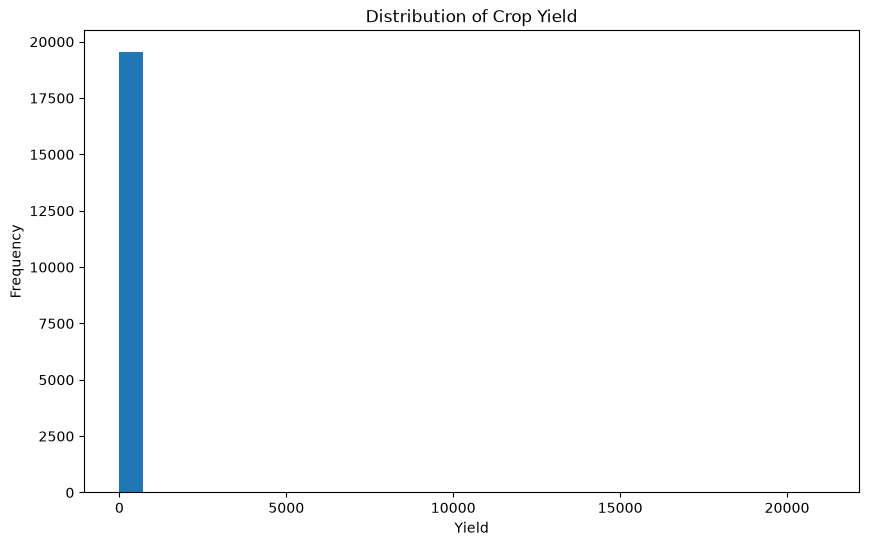

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["Yield"].dropna(), bins=30)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.show()

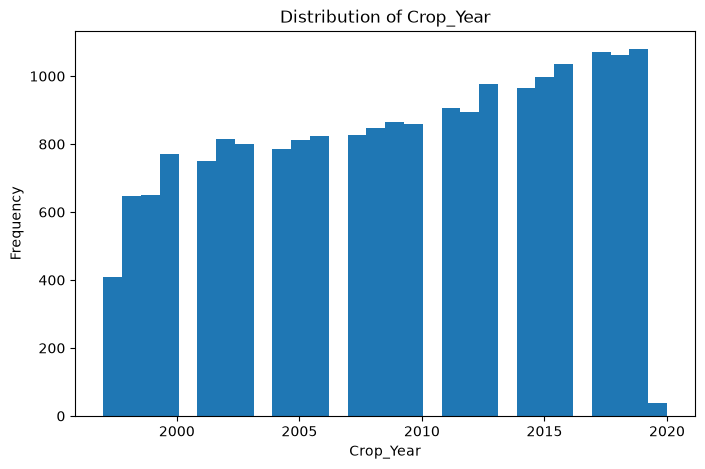

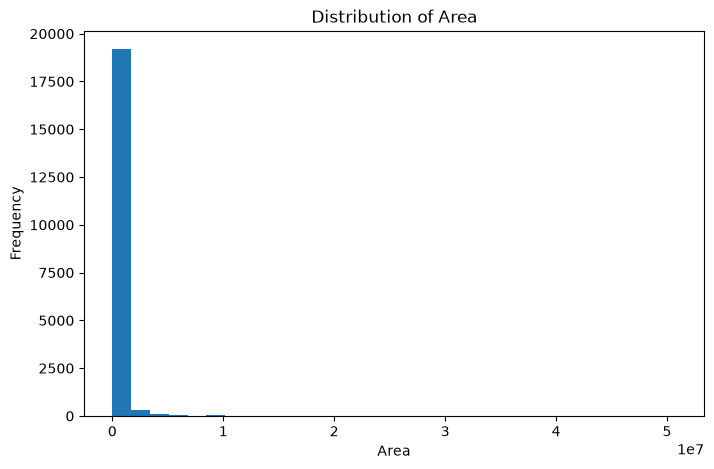

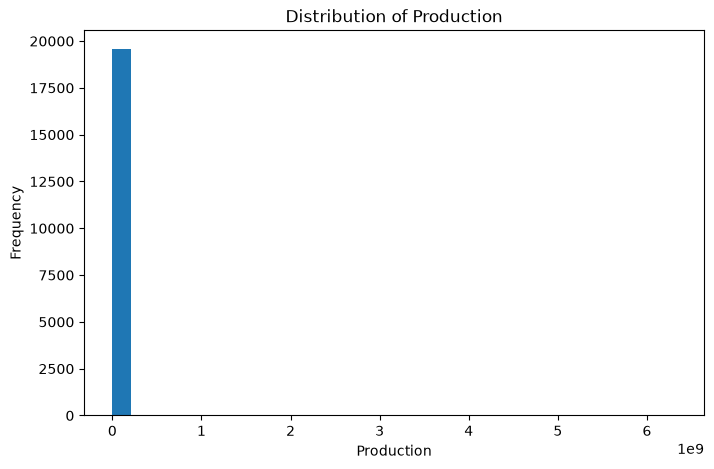

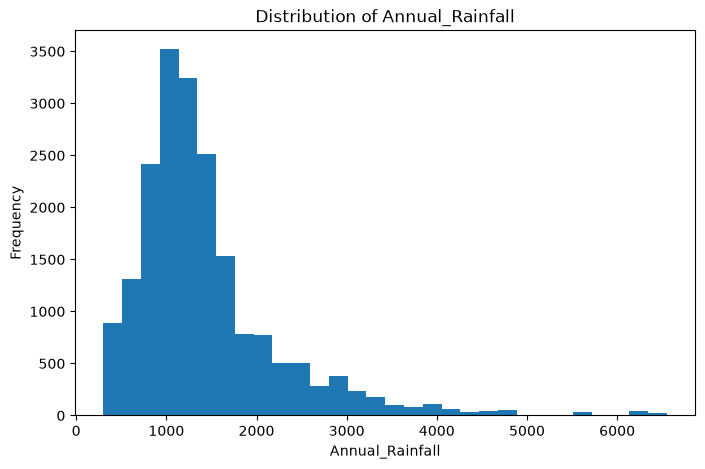

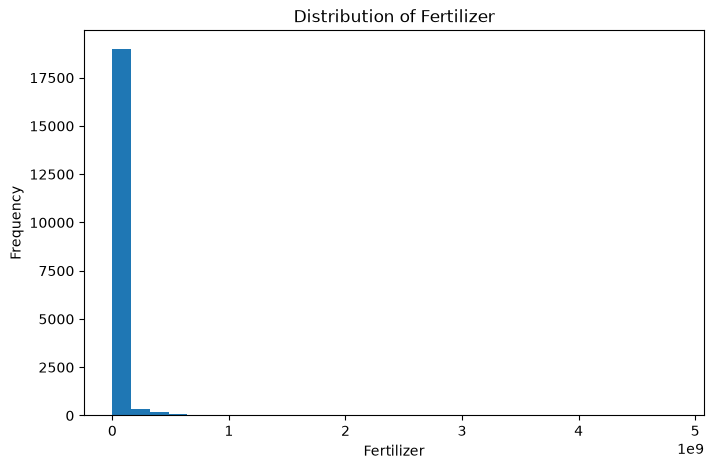

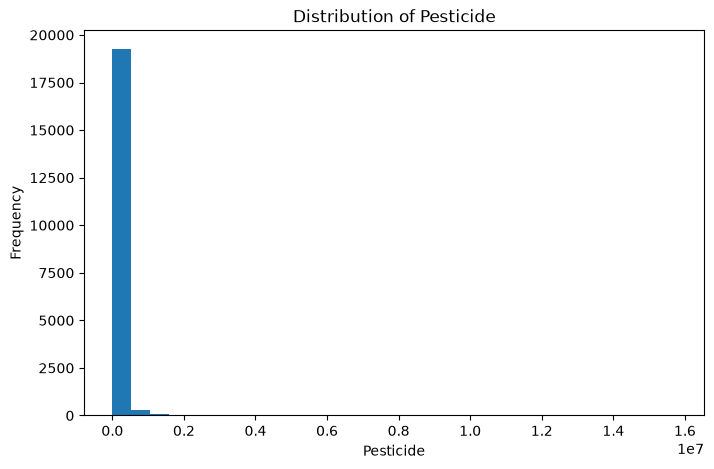

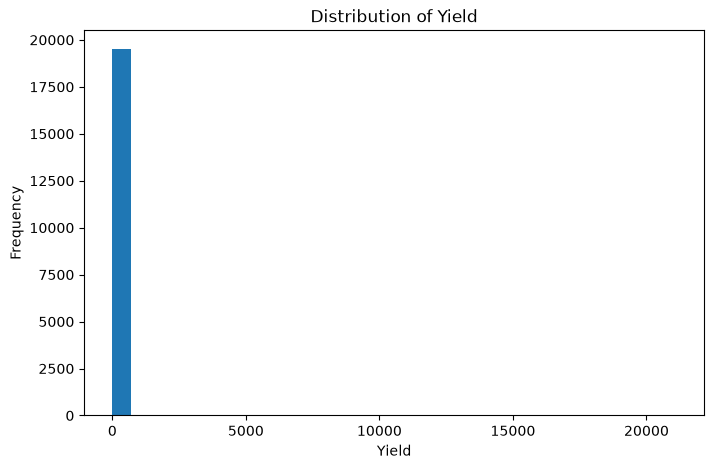

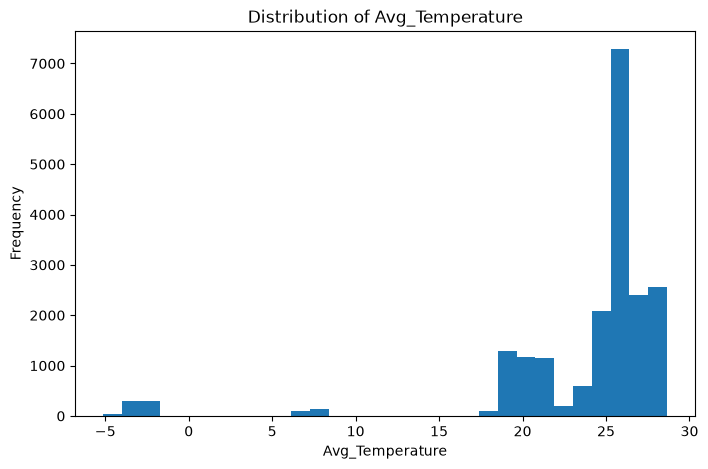

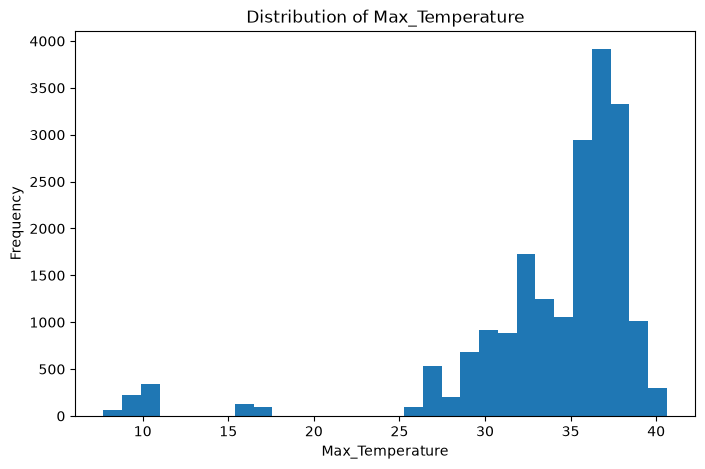

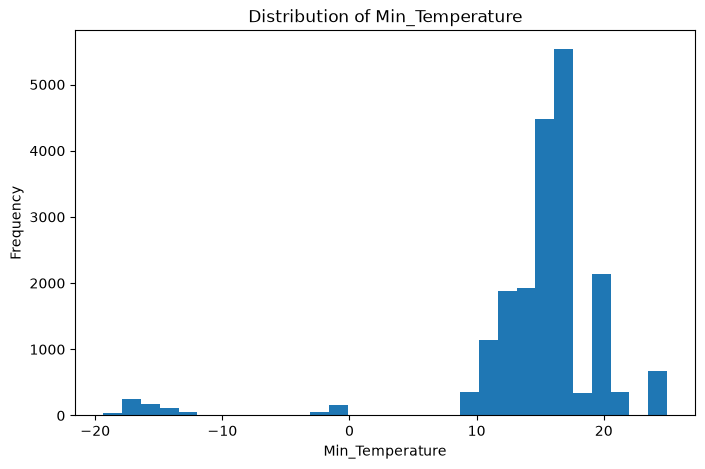

In [28]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column].dropna(), bins=30)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [29]:
# Numerical vs Categorical Features

numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']
Categorical Features: ['Crop', 'Season', 'State']


C:\Users\Manisha\AppData\Local\Temp\ipykernel_11060\2398746110.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns


C:\Users\Manisha\AppData\Local\Temp\ipykernel_11060\1831850744.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


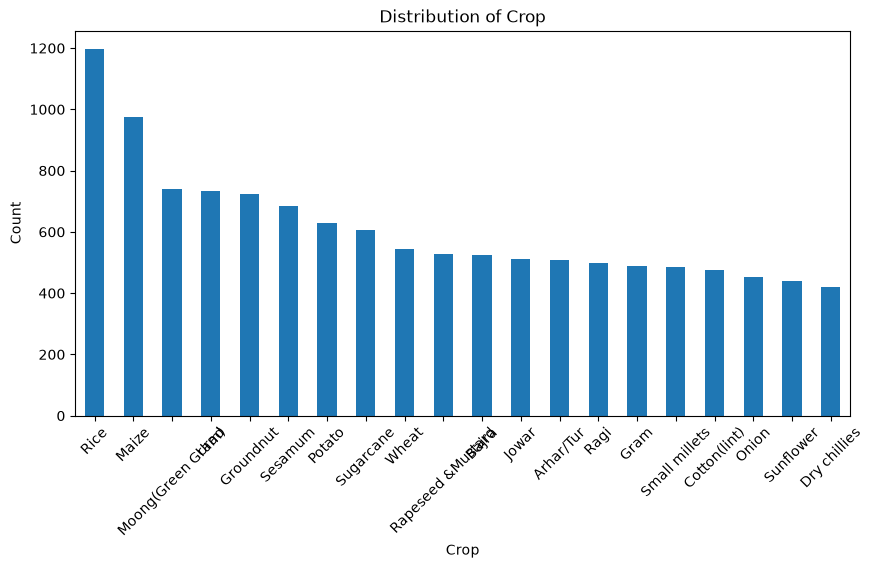

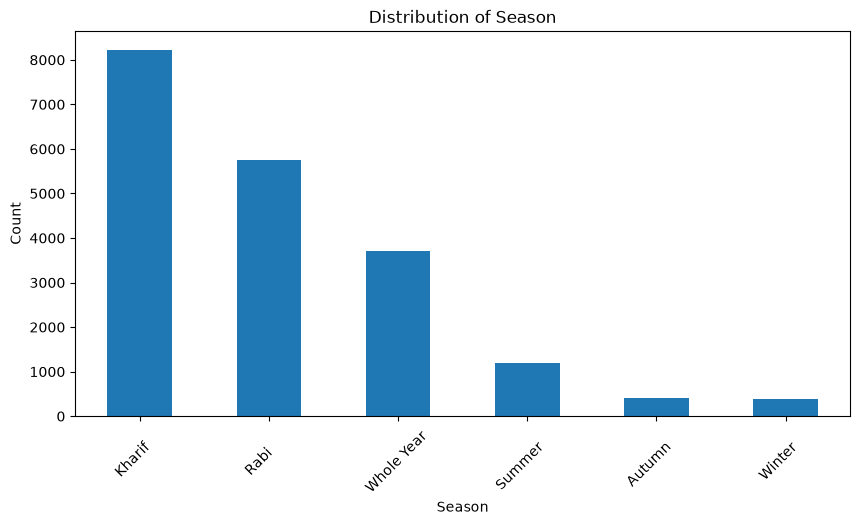

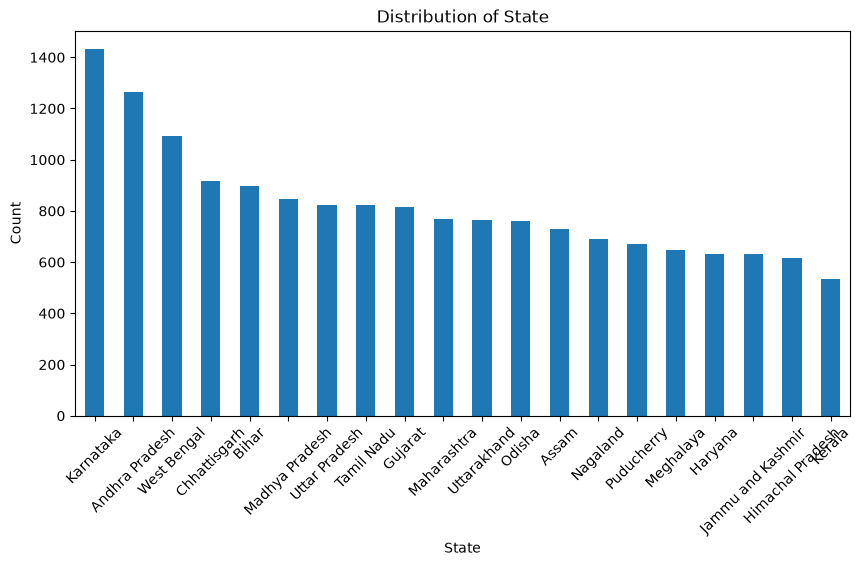

In [30]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    plt.figure(figsize=(10, 5))
    
    df[column].value_counts().head(20).plot(kind="bar")
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    
    plt.show()

### Observation

The histogram shows the distribution of the target variable `Yield`. It helps identify the range, concentration, and spread of crop yield values. The distribution can also indicate whether extreme or unusual yield values are present.

In [31]:
# Select only numerical columns for correlation analysis

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = df[numerical_cols].corr()

corr_matrix

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
Crop_Year,1.000000,-0.035686,0.003366,-0.011070,0.011126,-0.004654,0.002532,-0.021920,-0.052967,-0.007074
Area,-0.035686,1.000000,0.037441,-0.106042,0.973255,0.973478,0.001857,0.082820,0.113578,0.042066
Production,0.003366,0.037441,1.000000,0.029884,0.039797,0.035171,0.570808,0.024579,0.011166,0.039170
Annual_Rainfall,-0.011070,-0.106042,0.029884,1.000000,-0.109699,-0.097645,0.020812,-0.217049,-0.373690,-0.063685
Fertilizer,0.011126,0.973255,0.039797,-0.109699,1.000000,0.954992,0.002859,0.085136,0.116238,0.042821
Pesticide,-0.004654,0.973478,0.035171,-0.097645,0.954992,1.000000,0.001781,0.077598,0.106829,0.038672
Yield,0.002532,0.001857,0.570808,0.020812,0.002859,0.001781,1.000000,0.039344,0.018738,0.057605
Avg_Temperature,-0.021920,0.082820,0.024579,-0.217049,0.085136,0.077598,0.039344,1.000000,0.960134,0.963461
Max_Temperature,-0.052967,0.113578,0.011166,-0.373690,0.116238,0.106829,0.018738,0.960134,1.000000,0.855896
Min_Temperature,-0.007074,0.042066,0.039170,-0.063685,0.042821,0.038672,0.057605,0.963461,0.855896,1.000000


In [32]:
# Print Correlation Matrix

print("\n--- Crop Yield Correlation Matrix ---")
print(corr_matrix)


--- Crop Yield Correlation Matrix ---
                 Crop_Year      Area  Production  Annual_Rainfall  Fertilizer  \
Crop_Year         1.000000 -0.035686    0.003366        -0.011070    0.011126   
Area             -0.035686  1.000000    0.037441        -0.106042    0.973255   
Production        0.003366  0.037441    1.000000         0.029884    0.039797   
Annual_Rainfall  -0.011070 -0.106042    0.029884         1.000000   -0.109699   
Fertilizer        0.011126  0.973255    0.039797        -0.109699    1.000000   
Pesticide        -0.004654  0.973478    0.035171        -0.097645    0.954992   
Yield             0.002532  0.001857    0.570808         0.020812    0.002859   
Avg_Temperature  -0.021920  0.082820    0.024579        -0.217049    0.085136   
Max_Temperature  -0.052967  0.113578    0.011166        -0.373690    0.116238   
Min_Temperature  -0.007074  0.042066    0.039170        -0.063685    0.042821   

                 Pesticide     Yield  Avg_Temperature  Max_Temperatur

# Correlation Heatmap

To identify the relationship among numerical features and understand which
variables are positively or negatively correlated with crop yield before
model development.

A correlation heatmap visualizes the Pearson correlation coefficient between
numerical features.

The correlation coefficient (r) ranges from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

Generally:

- **0.70 to 1.00** → Strong positive correlation
- **0.40 to 0.69** → Moderate positive correlation
- **0.00 to 0.39** → Weak positive correlation
- **-0.40 to -0.69** → Moderate negative correlation
- **-0.70 to -1.00** → Strong negative correlation

## Examples and Observations

### 1. Area vs Production

**Observation:**
- A positive correlation indicates that larger cultivated areas
  generally tend to produce higher total crop production.
- This relationship can help understand the influence of cultivated
  area on production.

### 2. Fertilizer vs Yield

**Observation:**
- The correlation value indicates the strength and direction of the
  relationship between fertilizer usage and crop yield.
- A positive correlation suggests that higher fertilizer usage is
  associated with higher yield.

### 3. Annual Rainfall vs Yield

**Observation:**
- The correlation value shows whether rainfall has a positive or
  negative linear relationship with crop yield.
- This helps identify the importance of rainfall as an agricultural
  factor.

### 4. Temperature vs Yield

**Observation:**
- Average, maximum, and minimum temperature can be compared with yield
  using the correlation matrix.
- A positive or negative correlation indicates the direction of the
  linear relationship.

### 5. Production vs Yield

**Observation:**
- The correlation between production and yield helps understand the
  relationship between total crop production and yield.
- However, correlation does not imply causation.

### Overall Observation

The correlation heatmap helps identify numerical features that have
stronger relationships with the target variable **Yield**. These
relationships can provide useful insights during feature analysis and
model development.

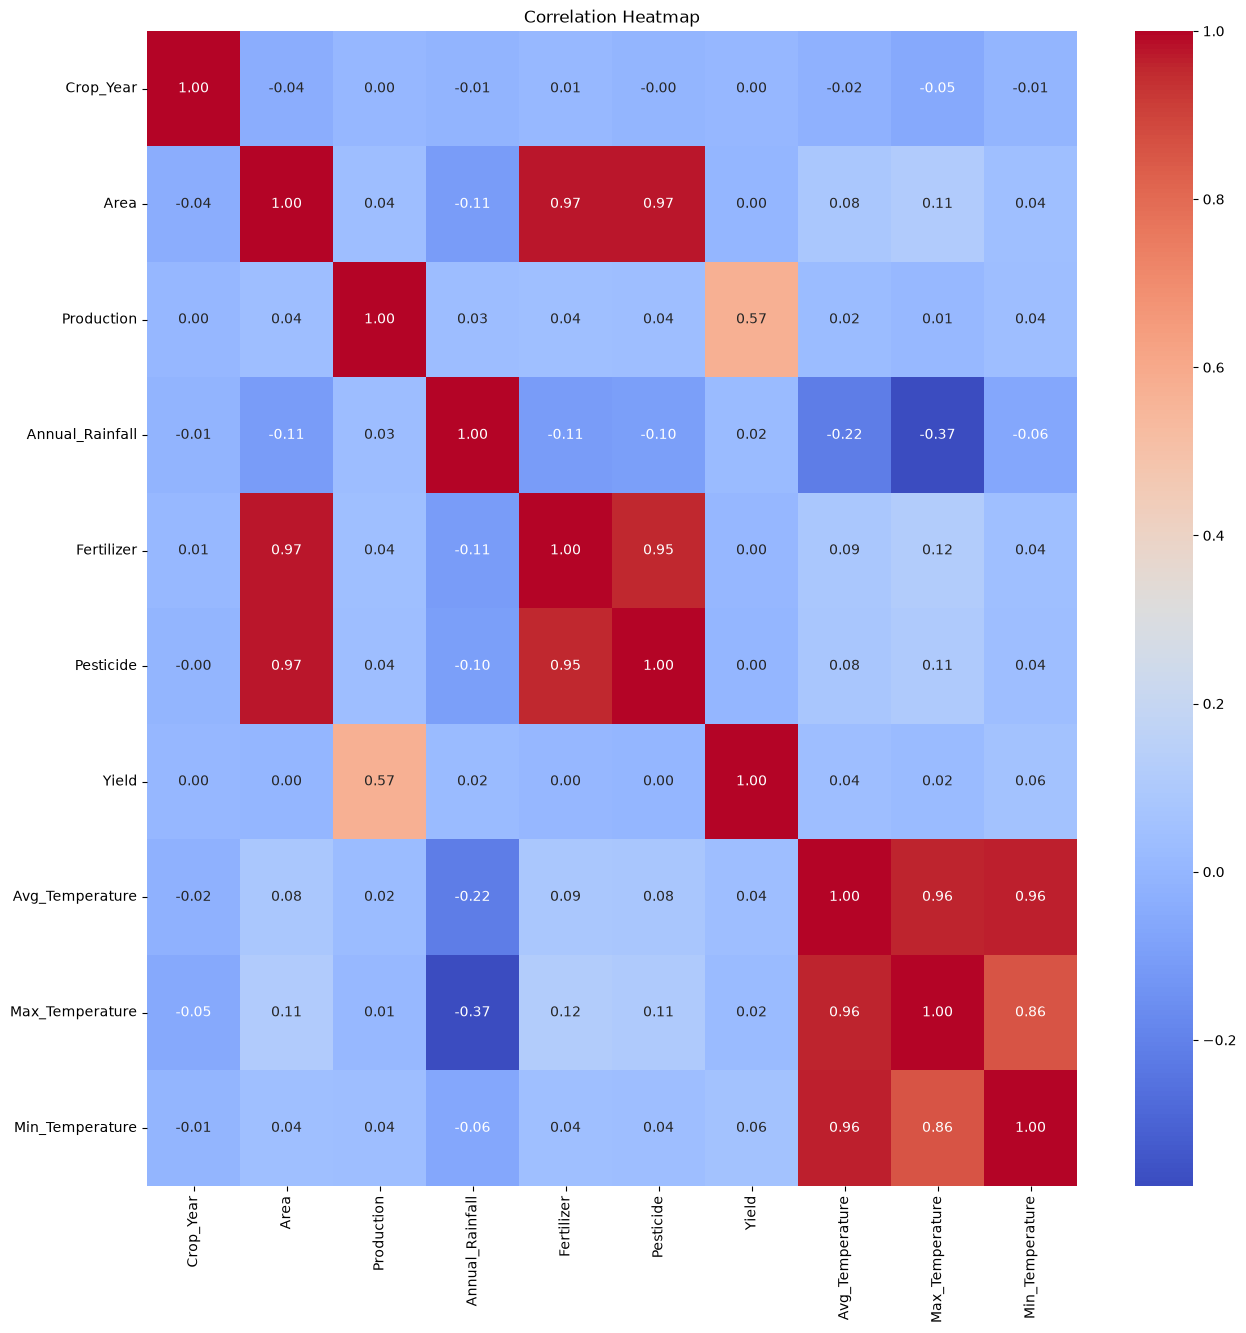

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Create heatmap
plt.figure(figsize=(15, 15))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [34]:
yield_correlation = df.corr(numeric_only=True)["Yield"].sort_values(
    ascending=False
)

print("========== CORRELATION WITH YIELD ==========")
print(yield_correlation)

========== CORRELATION WITH YIELD ==========
Yield              1.000000
Production         0.570808
Min_Temperature    0.057605
Avg_Temperature    0.039344
Annual_Rainfall    0.020812
Max_Temperature    0.018738
Fertilizer         0.002859
Crop_Year          0.002532
Area               0.001857
Pesticide          0.001781
Name: Yield, dtype: float64


### Observation

The correlation values show the strength and direction of the linear relationship between numerical features and crop yield.

A positive correlation indicates that the variables tend to increase together, while a negative correlation indicates an inverse relationship. Correlation does not necessarily imply causation.

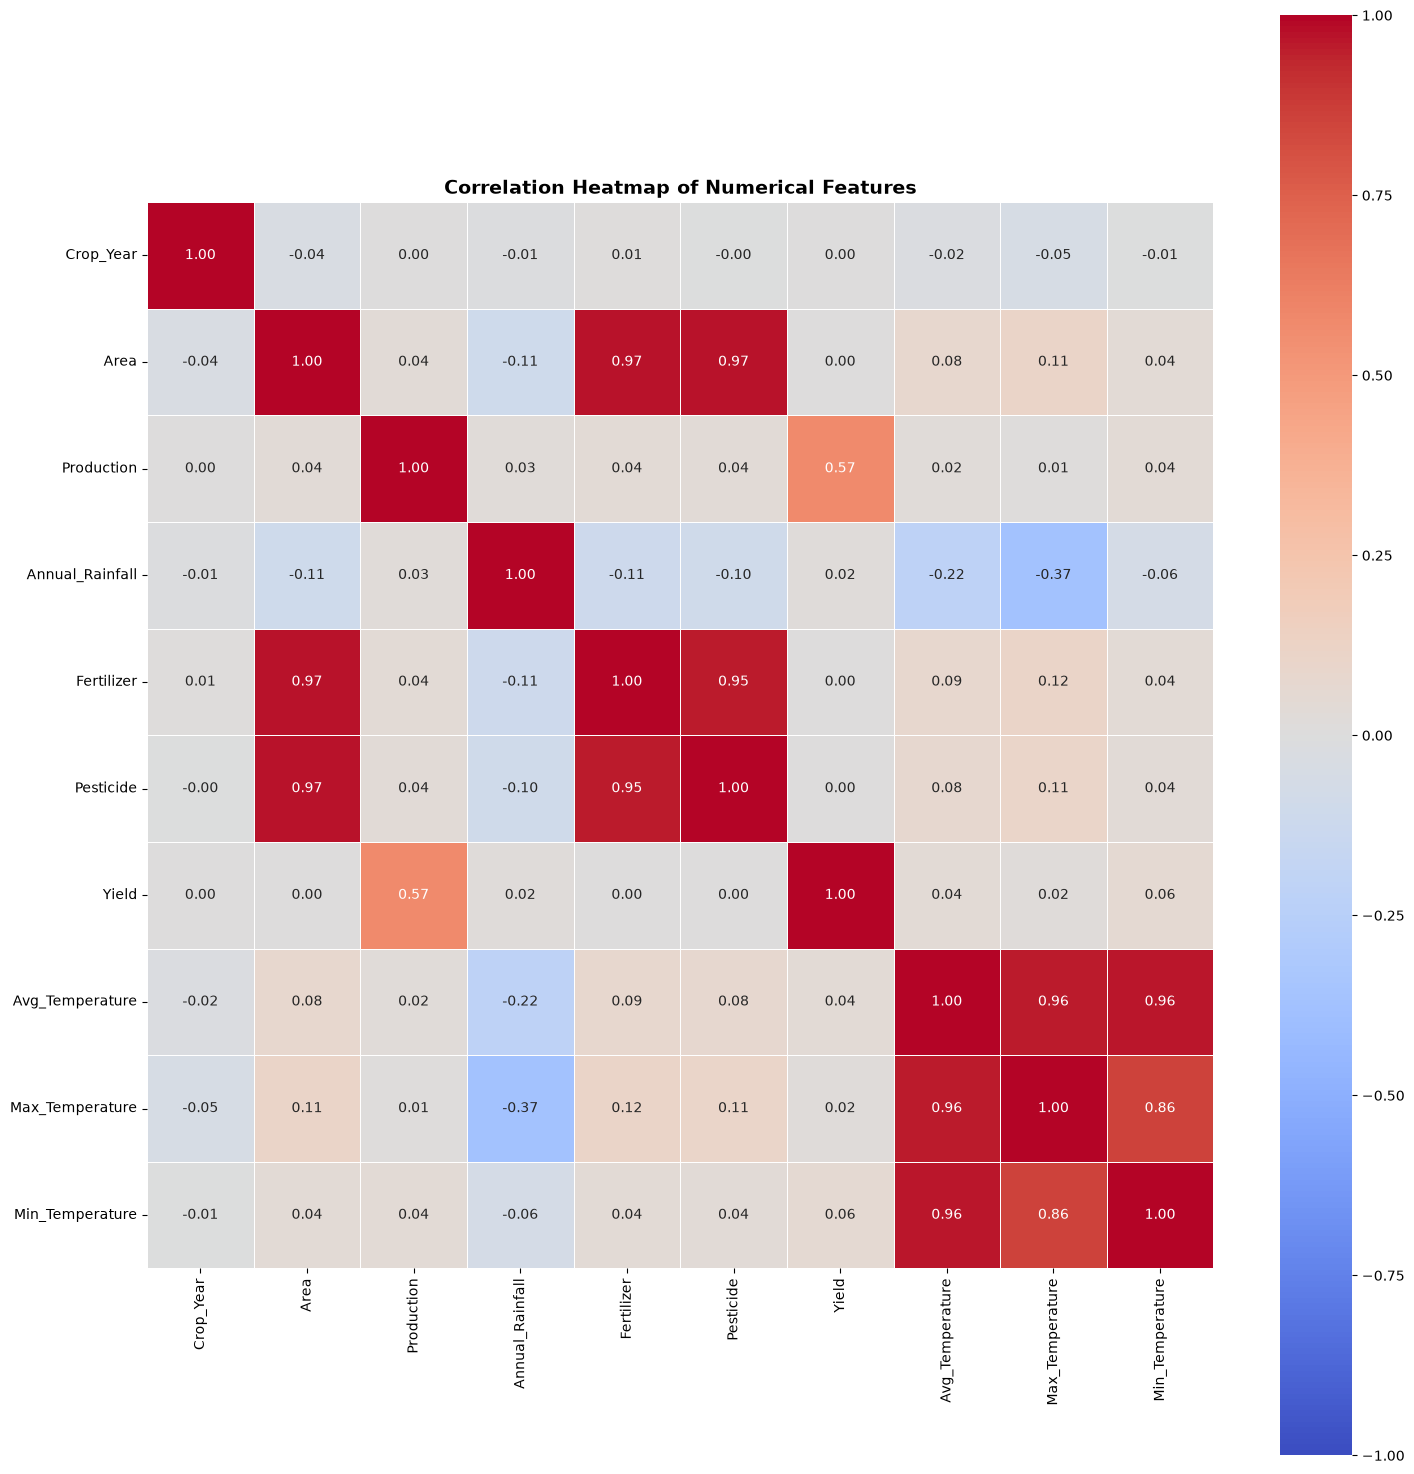

Exported heatmap to: C:\Crop Yield Prediction\outputs\correlation_heatmap.png


In [35]:
# Create Heatmap

import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(15, 15))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

# Export Heatmap
output_dir = r"C:\Crop Yield Prediction\outputs"

# Create output folder if it does not exist
os.makedirs(output_dir, exist_ok=True)

heatmap_path = os.path.join(
    output_dir,
    "correlation_heatmap.png"
)

plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"Exported heatmap to: {heatmap_path}")

In [36]:

print(os.getcwd())

c:\Crop Yield Prediction\notebooks


In [37]:
import numpy as np

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

Numerical columns:
['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature']


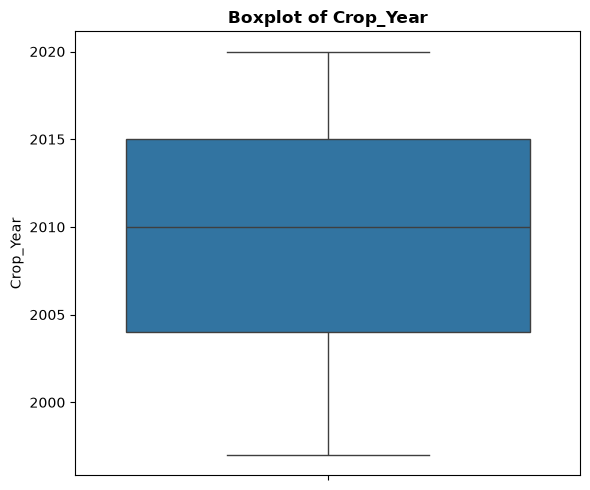

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Crop_Year.png


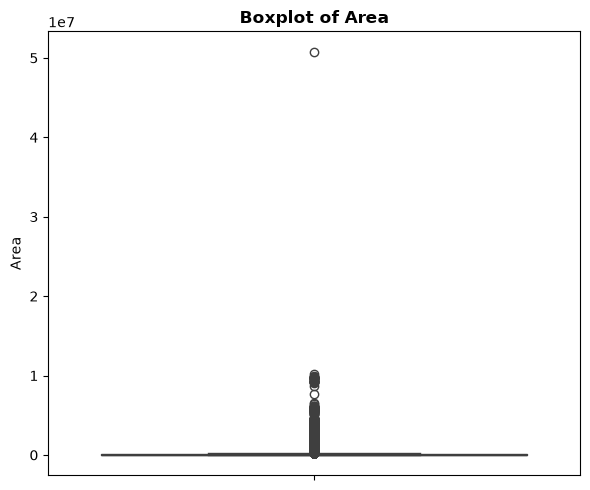

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Area.png


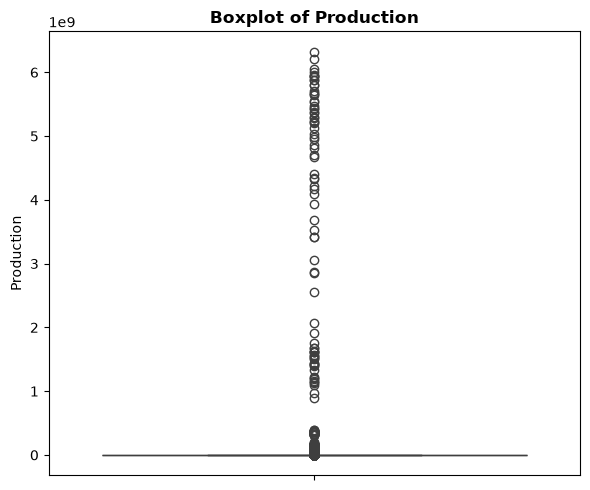

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Production.png


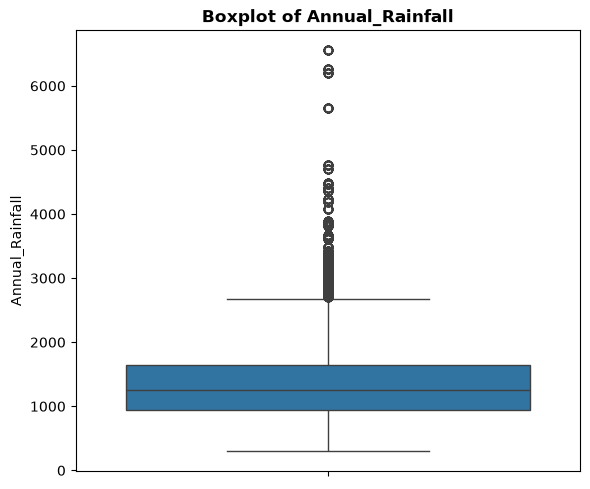

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Annual_Rainfall.png


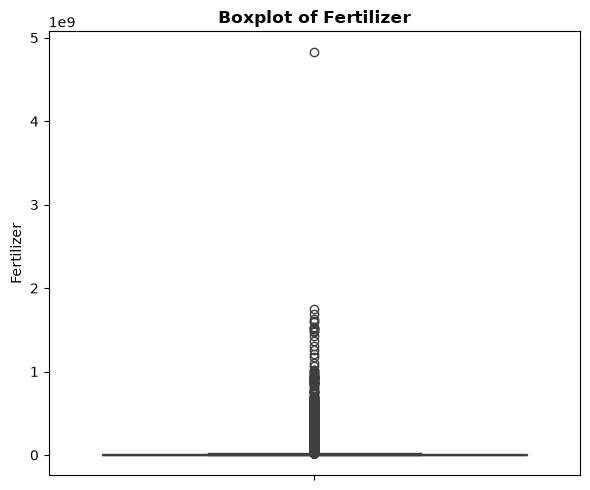

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Fertilizer.png


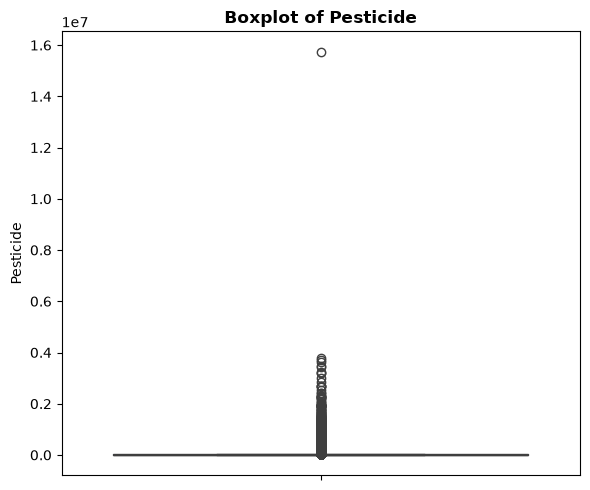

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Pesticide.png


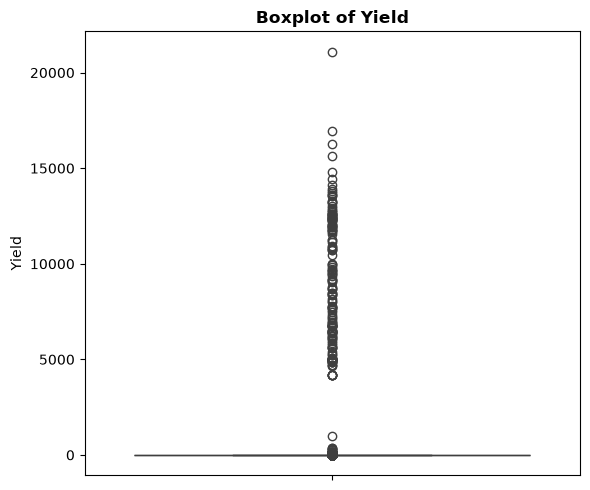

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Yield.png


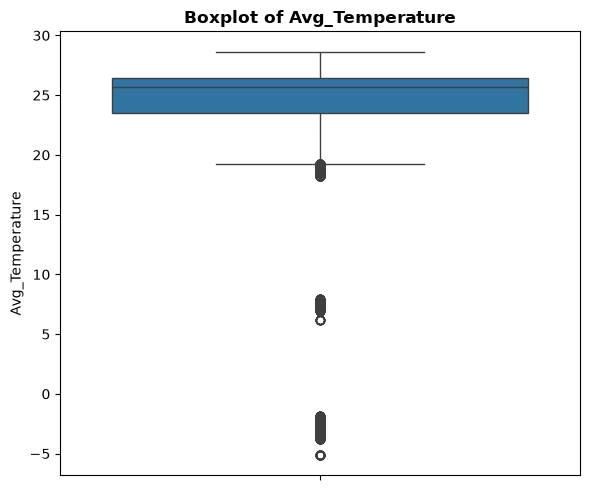

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Avg_Temperature.png


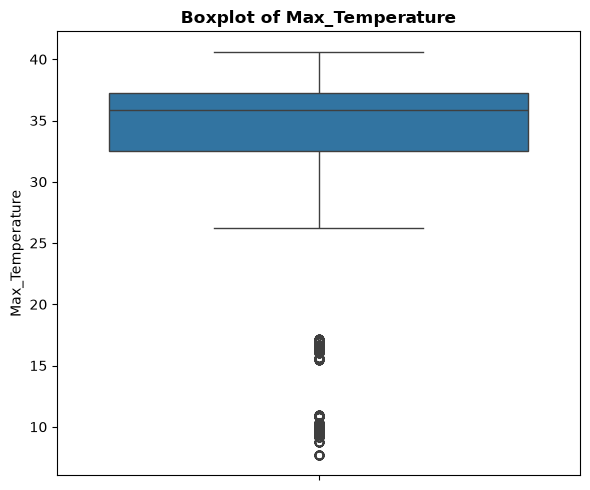

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Max_Temperature.png


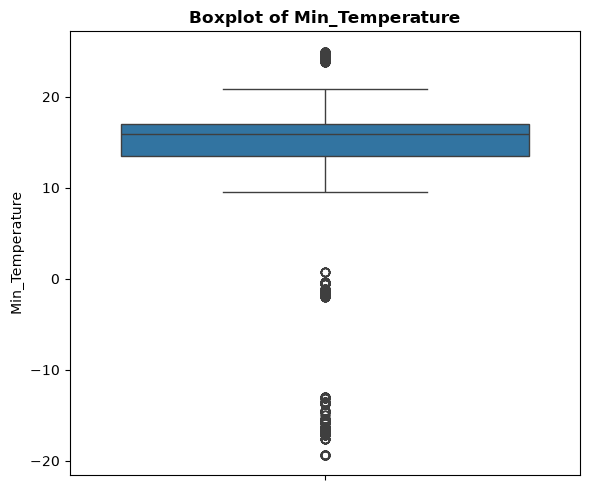

Exported boxplot to: C:\Crop Yield Prediction\outputs\boxplot_Min_Temperature.png

All boxplots generated successfully!


In [38]:
# -------------------------------------------------------------
# 3. Produce Boxplots for Numerical Features
# -------------------------------------------------------------

for col in numerical_cols:

    plt.figure(figsize=(6, 5))

    sns.boxplot(y=df[col])

    plt.title(
        f"Boxplot of {col}",
        fontsize=12,
        fontweight="bold"
    )

    plt.ylabel(col)
    plt.tight_layout()

    # Save the boxplot
    boxplot_filename = f"boxplot_{col}.png"
    boxplot_path = os.path.join(output_dir, boxplot_filename)

    plt.savefig(
        boxplot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"Exported boxplot to: {boxplot_path}")

print("\nAll boxplots generated successfully!")

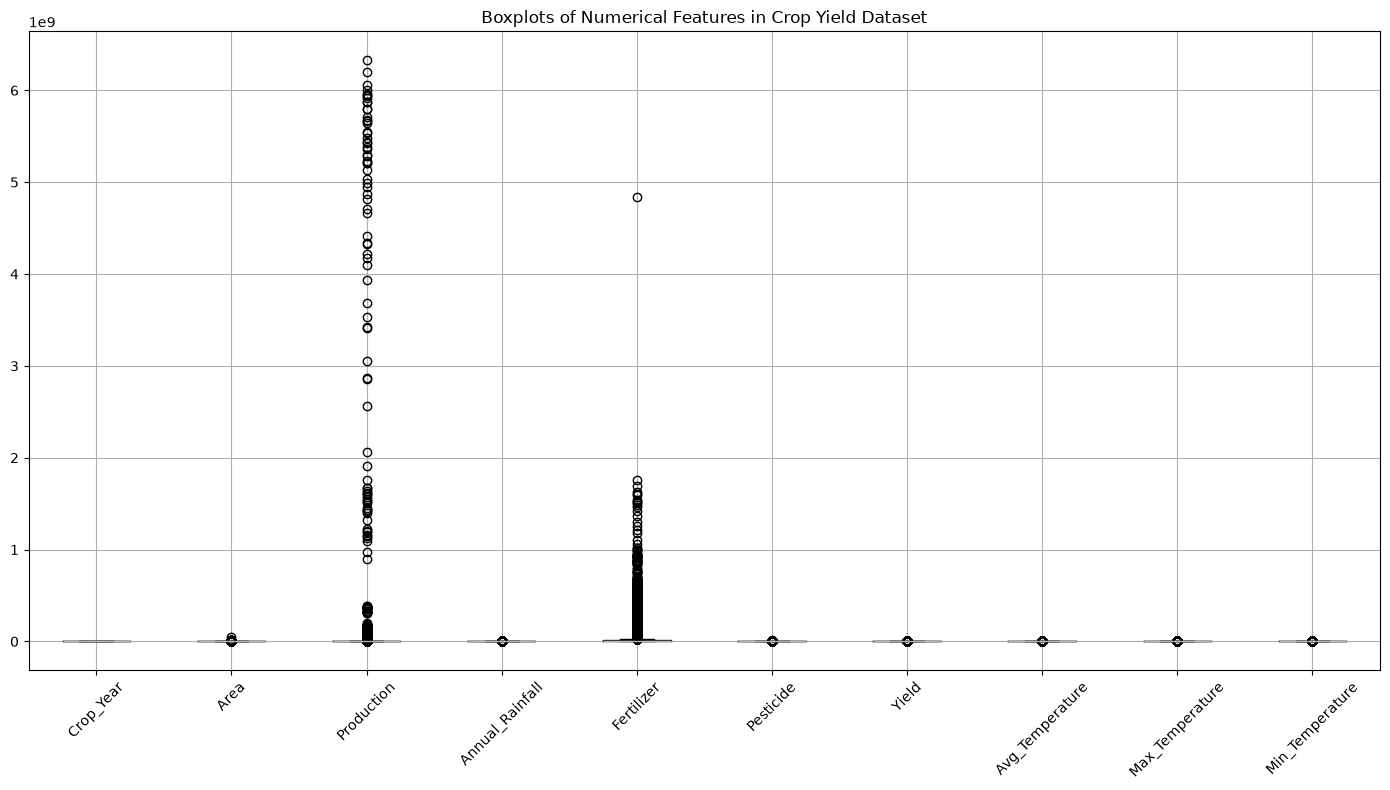

In [39]:
# Boxplots of Numerical Features

numerical_columns = [
    "Crop_Year",
    "Area",
    "Production",
    "Annual_Rainfall",
    "Fertilizer",
    "Pesticide",
    "Yield",
    "Avg_Temperature",
    "Max_Temperature",
    "Min_Temperature"
]

fig6 = plt.figure(figsize=(14, 8))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.title("Boxplots of Numerical Features in Crop Yield Dataset")

plt.tight_layout()

plt.show()

<module 'matplotlib.pyplot' from 'c:\\Crop Yield Prediction\\.MLvenv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

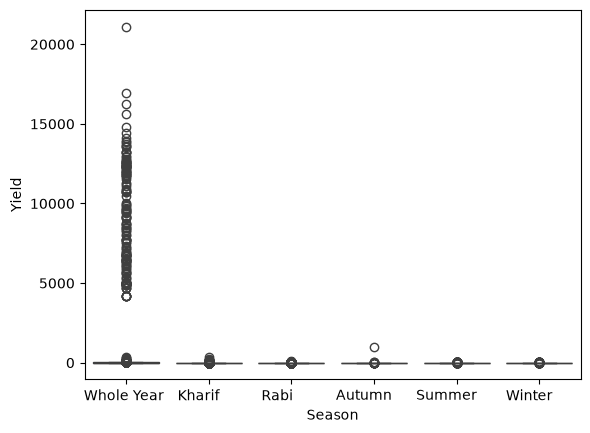

In [40]:
fig7 = sns.boxplot(
    x="Season",
    y="Yield",
    data=df
)

plt

In [41]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import os

output_dir = r"C:\Crop Yield Prediction\outputs"
os.makedirs(output_dir, exist_ok=True)

pdf_path = os.path.join(output_dir, "EDA_Report.pdf")

with PdfPages(pdf_path) as pdf:

    # 1. Missing Values Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
    plt.title("Missing Values in Crop Yield Dataset")
    plt.xlabel("Features")
    plt.ylabel("Records")
    pdf.savefig()
    plt.close()

    # 2. Crop Yield Distribution
    plt.figure(figsize=(10, 6))
    sns.histplot(df["Yield"], kde=True)
    plt.title("Distribution of Crop Yield")
    plt.xlabel("Yield")
    plt.ylabel("Frequency")
    pdf.savefig()
    plt.close()

    # 3. Correlation Heatmap
    plt.figure(figsize=(15, 15))
    sns.heatmap(
        df.corr(numeric_only=True),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )
    plt.title("Correlation Heatmap of Numerical Features")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 4. Boxplots of Numerical Features
    numerical_columns = [
        "Crop_Year", "Area", "Production", "Annual_Rainfall",
        "Fertilizer", "Pesticide", "Yield",
        "Avg_Temperature", "Max_Temperature", "Min_Temperature"
    ]

    plt.figure(figsize=(14, 8))
    df[numerical_columns].boxplot()
    plt.xticks(rotation=45)
    plt.title("Boxplots of Numerical Features")
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # 5. Yield by Season
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Season", y="Yield", data=df)
    plt.title("Crop Yield Distribution by Season")
    plt.xlabel("Season")
    plt.ylabel("Yield")
    plt.xticks(rotation=45)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

print(f"EDA Report saved successfully at:\n{pdf_path}")

EDA Report saved successfully at:
C:\Crop Yield Prediction\outputs\EDA_Report.pdf


In [42]:
season_yield = df.groupby("Season")["Yield"].agg(
    ["mean", "median", "min", "max"]
).sort_values("mean", ascending=False)

season_yield

,mean,median,min,max
Season,,,,
Whole Year,412.995471,4.295,0.000,21105.000
Winter,5.287262,1.545,0.113,68.230
Autumn,3.917498,1.092,0.157,989.870
Summer,2.997367,1.674,0.000,69.367
Kharif,2.482208,0.924,0.000,381.420
Rabi,1.988516,0.903,0.000,80.268


In [43]:
state_yield = df.groupby("State")["Yield"].agg(
    ["mean", "median", "min", "max"]
).sort_values("mean", ascending=False)

state_yield.head(20)

,mean,median,min,max
State,,,,
Goa,354.780305,2.0300,0.000,6359.690
Puducherry,346.512842,1.9350,0.000,14410.517
Kerala,276.611159,1.7000,0.000,6884.551
West Bengal,266.898323,0.9500,0.000,13592.128
Tamil Nadu,226.050229,1.4870,0.000,14134.659
Assam,219.716360,0.8190,0.238,9156.942
Andhra Pradesh,181.465391,1.1320,0.000,16935.058
Karnataka,105.720581,1.0120,0.000,9984.488
Telangana,99.518199,1.3150,0.000,21105.000


In [44]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append([column, outliers])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Number of Outliers"]
)

outlier_summary

,Feature,Number of Outliers
0,Crop_Year,0
1,Area,3076
2,Production,3373
3,Annual_Rainfall,1527
4,Fertilizer,3093
5,Pesticide,3036
6,Yield,3065
7,Avg_Temperature,1801
8,Max_Temperature,857
9,Min_Temperature,1527


# EDA Observations and Inferences

1. Yield is a continuous numerical variable, confirming that this is a regression problem.

2. The dataset contains both numerical and categorical features.

3. Crop, Season, and State contain categorical information that may influence crop yield.

4. Yield varies across different crop types.

5. Yield also varies across seasons and states.

6. Annual rainfall, fertilizer, pesticide, area, production, and temperature variables were analyzed to understand their relationship with Yield.

7. The correlation matrix helps identify numerical features having stronger or weaker linear relationships with Yield.

8. Boxplots and the IQR method were used to identify possible outliers.

9. Outliers were not automatically removed because extreme agricultural values may represent genuine observations.

10. The EDA indicates that crop yield may depend on multiple numerical and categorical variables.

11. Therefore, Random Forest, XGBoost, and SVR will be compared for crop yield prediction.